In [5]:
import xarray as xr
import os
import torch
import numpy as np

In [6]:
os.environ["OMP_NUM_THREADS"] = "1"
data_path = "/data/jingren/repository/dataset/HadCRUT_5/1_to_10_netcdf/HadCRUT.5.0.2.0.anomalies.1.nc"
ds = xr.open_dataset(data_path)
print(ds)

<xarray.Dataset> Size: 44MB
Dimensions:         (time: 2101, latitude: 36, longitude: 72, bnds: 2)
Coordinates:
  * time            (time) datetime64[ns] 17kB 1850-01-16T12:00:00 ... 2025-0...
  * latitude        (latitude) float64 288B -87.5 -82.5 -77.5 ... 77.5 82.5 87.5
  * longitude       (longitude) float64 576B -177.5 -172.5 ... 172.5 177.5
    realization     int64 8B ...
Dimensions without coordinates: bnds
Data variables:
    tas             (time, latitude, longitude) float64 44MB ...
    time_bnds       (time, bnds) datetime64[ns] 34kB ...
    latitude_bnds   (latitude, bnds) float64 576B ...
    longitude_bnds  (longitude, bnds) float64 1kB ...
Attributes:
    comment:      2m air temperature over land blended with sea water tempera...
    history:      Data set built at: 2025-03-07T17:07:52+00:00
    institution:  Met Office Hadley Centre / Climatic Research Unit, Universi...
    licence:      HadCRUT5 is licensed under the Open Government Licence v3.0...
    reference:   

In [7]:
temperature = ds["tas"]

In [9]:
temperature.shape

(2101, 36, 72)

In [24]:
print(temperature[2100, 20, 60])

<xarray.DataArray 'tas' ()> Size: 8B
[1 values with dtype=float64]
Coordinates:
    time         datetime64[ns] 8B 2025-01-16T12:00:00
    latitude     float64 8B 12.5
    longitude    float64 8B 122.5
    realization  int64 8B ...
Attributes:
    long_name:     blended air_temperature_anomaly over land with sea_water_t...
    units:         K
    cell_methods:  area: mean (interval: 5.0 degrees_north 5.0 degrees_east) ...


In [25]:
temperature = torch.tensor(temperature.values)

In [31]:
temperature.shape
mask = ~torch.isnan(temperature)

In [33]:
mask[0,:,:]

tensor([[False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        ...,
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False]])

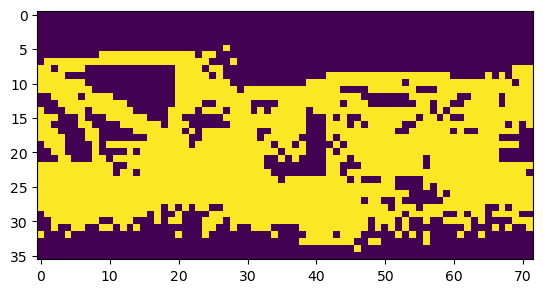

In [36]:
plt.imshow(mask[1000,:,:].float())

In [16]:
data_path_2 = "/data/jingren/repository/dataset/HadCRUT_5/HadCRUT.5.0.2.0.summary_series.global.monthly.nc"
ds_1 = xr.open_dataset(data_path_2)

In [18]:
print(ds_1)

<xarray.Dataset> Size: 101kB
Dimensions:                  (time: 2102, bnds: 2)
Coordinates:
  * time                     (time) datetime64[ns] 17kB 1850-01-16T12:00:00 ....
    latitude                 float64 8B ...
    longitude                float64 8B ...
    realization              int64 8B ...
    latitude_vector_1        float64 8B ...
    latitude_vector_2        float64 8B ...
    location_index_1         int64 8B ...
    location_index_2         int64 8B ...
    longitude_vector_1       float64 8B ...
    longitude_vector_2       float64 8B ...
Dimensions without coordinates: bnds
Data variables: (12/13)
    tas_mean                 (time) float64 17kB ...
    time_bnds                (time, bnds) datetime64[ns] 34kB ...
    latitude_bnds            (bnds) float64 16B ...
    longitude_bnds           (bnds) float64 16B ...
    realization_bnds         (bnds) int64 16B ...
    tas_lower                (time) float64 17kB ...
    ...                       ...
    latitude_ve

In [19]:
tas = ds_1["tas_mean"]

In [20]:
tas.shape

(2102,)

In [14]:
import os
import xarray as xr
os.environ["OMP_NUM_THREADS"] = "1"
data_path = "/data/jingren/repository/dataset/HadCRUT_5/HadCRUT.5.0.2.0.analysis.anomalies.1.nc"
ds = xr.open_dataset(data_path)
print(ds)

<xarray.Dataset> Size: 44MB
Dimensions:         (time: 2102, latitude: 36, longitude: 72, bnds: 2)
Coordinates:
  * time            (time) datetime64[ns] 17kB 1850-01-16T12:00:00 ... 2025-0...
  * latitude        (latitude) float64 288B -87.5 -82.5 -77.5 ... 77.5 82.5 87.5
  * longitude       (longitude) float64 576B -177.5 -172.5 ... 172.5 177.5
    realization     int64 8B ...
Dimensions without coordinates: bnds
Data variables:
    tas             (time, latitude, longitude) float64 44MB ...
    time_bnds       (time, bnds) datetime64[ns] 34kB ...
    latitude_bnds   (latitude, bnds) float64 576B ...
    longitude_bnds  (longitude, bnds) float64 1kB ...
Attributes:
    comment:      2m air temperature over land blended with sea water tempera...
    history:      Data set built at: 2025-04-30T17:33:58+00:00
    institution:  Met Office Hadley Centre / Climatic Research Unit, Universi...
    licence:      HadCRUT5 is licensed under the Open Government Licence v3.0...
    reference:   

In [15]:
tas = ds["tas"]

In [16]:
tas.shape

(2102, 36, 72)

In [17]:
import torch
tas = torch.tensor(tas.values)

In [24]:
tas

tensor([[[    nan,     nan,     nan,  ...,     nan,     nan,     nan],
         [    nan,     nan,     nan,  ...,     nan,     nan,     nan],
         [    nan,     nan,     nan,  ...,     nan,     nan,     nan],
         ...,
         [    nan,     nan,     nan,  ...,     nan,     nan,     nan],
         [    nan,     nan,     nan,  ...,     nan,     nan,     nan],
         [    nan,     nan,     nan,  ...,     nan,     nan,     nan]],

        [[    nan,     nan,     nan,  ...,     nan,     nan,     nan],
         [    nan,     nan,     nan,  ...,     nan,     nan,     nan],
         [    nan,     nan,     nan,  ...,     nan,     nan,     nan],
         ...,
         [    nan,     nan,     nan,  ...,     nan,     nan,     nan],
         [    nan,     nan,     nan,  ...,     nan,     nan,     nan],
         [    nan,     nan,     nan,  ...,     nan,     nan,     nan]],

        [[    nan,     nan,     nan,  ...,     nan,     nan,     nan],
         [    nan,     nan,     nan,  ...,   

In [29]:
tas = torch.nan_to_num(tas, nan=0.0)
tas[2101, :, :].min()

tensor(-2.2576, dtype=torch.float64)